--- Skrip Pengujian Multi-Model LightGBM (Dataset Terpisah) Dimulai ---

[Langkah 1A] Memuat Model 1 (Dataset  DL)...
  Model berhasil dimuat dari: trained_models_lightgbm_aggregated\DL_filtered_1_lgbm.joblib

[Langkah 1B] Memuat Model 2 (Dataset  UL)...
  Model berhasil dimuat dari: trained_models_lightgbm_aggregated\UL_filtered_1_lgbm.joblib

[Langkah 2] Memuat dan mempersiapkan data pengujian...
  Memuat dataset Model 1 dari: D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/DL_fill.xlsx...
    Dataset Model 1 dimuat: 72480 baris.
    Data Model 1: Baris setelah cleaning targets: 72478
  Memuat dataset Model 2 dari: D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/UL_fill.xlsx...
    Dataset Model 2 dimuat: 72480 baris.
    Data Model 2: Baris setelah cleaning targets: 72478
  Menggabungkan dataset pengujian Model 1 dan Model 2 berdasarkan ['Time', 'Latitude', 'Longitude']...
  Jumlah baris setelah merge: 1714396

[Langkah 3] Menerapkan filter pada data pengujian gabungan...


C:\Users\deeric\AppData\Local\Temp\ipykernel_1396\650887270.py:127: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(error_arrays_dict))


  Median Error (Dataset  UL): 0.76m
  CDF comparison plot saved to: results_lgbm_model_comparison_diff_datasets\CompareDiff_DL_filtered_1_vs_UL_filtered_1_subset_test_cdf_comparison.png


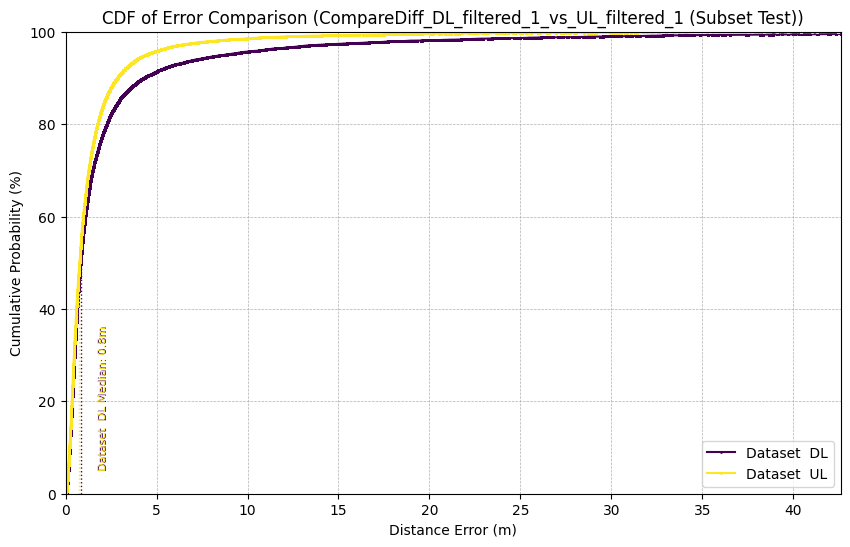


[Langkah 5] Membuat plot peta perbandingan untuk subset pengujian...
Memplot 857189 titik dari indeks 0-857188...


C:\Users\deeric\AppData\Local\Temp\ipykernel_1396\650887270.py:157: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors=plt.cm.get_cmap('Set1',len(model_pred_cols_map)); markers=['x','P','s','D','^']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import time
import os
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- ------------------------------------------------------------------ --- #
# ---               KONFIGURASI UTAMA (SESUAIKAN DI SINI)                --- #
# --- ------------------------------------------------------------------ --- #

# --- Path ke DATASET PENGUJIAN ---
# Kita sekarang punya dua file sumber, satu untuk fitur Model 1, satu untuk Model 2
# Asumsi keduanya memiliki kolom Time, Latitude, Longitude yang bisa disinkronkan
DATASET_PATH_MODEL_1 = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/DL_fill.xlsx'
DATASET_PATH_MODEL_2 = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/UL_fill.xlsx'

# --- Konfigurasi untuk MODEL 1 ---
MODEL_1_DIR_LGBM = "trained_models_lightgbm_aggregated"
MODEL_1_BASE_NAME = os.path.join(MODEL_1_DIR_LGBM, "DL_filtered_1")
MODEL_1_WAS_SCALED = False
MODEL_1_FEATURE_COLS = [ # Fitur yang ada di DATASET_PATH_MODEL_1
  'NR_UE_Pathloss_DL_0',
        'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
        'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0','NR_UE_Nbr_PCI_0',
    # ... fitur lain untuk Model 1 ...
]
MODEL_1_NAME_FOR_PLOT = "Dataset  DL"

# --- Konfigurasi untuk MODEL 2 ---
MODEL_2_DIR_LGBM = "trained_models_lightgbm_aggregated"
MODEL_2_BASE_NAME = os.path.join(MODEL_2_DIR_LGBM, "UL_filtered_1")
MODEL_2_WAS_SCALED = False
MODEL_2_FEATURE_COLS = [ # Fitur yang ada di DATASET_PATH_MODEL_2
 'NR_UE_Pathloss_DL_0',
        'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
        'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0','NR_UE_Nbr_PCI_0',
    # ... fitur lain untuk Model 2 ...
]
MODEL_2_NAME_FOR_PLOT = "Dataset  UL"

# Kolom Target (diasumsikan sama dan ada di kedua dataset sumber)
TARGET_COLS = ['Latitude', 'Longitude']
# Kolom Kunci untuk Menggabungkan Dua Dataset Sumber (selain Lat/Lon)
# Biasanya 'Time' adalah kunci utama. Pastikan formatnya konsisten.
KEY_COL_FOR_MERGE = ['Time'] # Bisa juga ['Time', 'ID_Unik_Event'] jika ada

# Definisi Filter untuk SUBSET DATA PENGUJIAN (diterapkan SETELAH merge)
TEST_SUBSET_FILTER_CONDITIONS = [
    # "DL_NR_UE_RSRP_0 < -100" # Gunakan nama kolom setelah di-prefix (jika ada) atau dari hasil merge
]
TEST_SUBSET_START_INDEX = 0
TEST_SUBSET_END_INDEX = 857189 #1714380/2 # Plot 50 titik pertama dari subset

# Output Configuration
RESULTS_DIR_COMPARISON = 'results_lgbm_model_comparison_diff_datasets'
COMPARISON_PREFIX = f"CompareDiff_{os.path.basename(MODEL_1_BASE_NAME)}_vs_{os.path.basename(MODEL_2_BASE_NAME)}"

# --- ------------------------------------------------------------------ --- #
# ---                      AKHIR KONFIGURASI UTAMA                       --- #
# --- ------------------------------------------------------------------ --- #

os.makedirs(RESULTS_DIR_COMPARISON, exist_ok=True)

# --- Fungsi Bantuan (Haversine, load_model, plot_cdf, plot_map_comparison, plot_fi bisa dipakai ulang) ---
def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

def load_trained_lgbm_model_and_scaler(base_model_filename, model_was_scaled):
    # ... (fungsi ini tetap sama) ...
    model_path = f"{base_model_filename}_lgbm.joblib"
    scaler_path = f"{base_model_filename}_scaler.joblib"
    loaded_model, loaded_scaler = None, None
    if os.path.exists(model_path):
        try: loaded_model = joblib.load(model_path); print(f"  Model berhasil dimuat dari: {model_path}")
        except Exception as e: print(f"  Error memuat model dari {model_path}: {e}"); return None, None
    else: print(f"  Error: File model tidak ditemukan di {model_path}"); return None, None
    if model_was_scaled:
        if os.path.exists(scaler_path):
            try: loaded_scaler = joblib.load(scaler_path); print(f"  Scaler berhasil dimuat dari: {scaler_path}")
            except Exception as e: print(f"  Error memuat scaler: {e}."); return loaded_model, None
        else: print(f"  Error: Scaler tidak ditemukan di {scaler_path}, model di-scale."); return loaded_model, None
    return loaded_model, loaded_scaler


def calculate_error_metrics_and_details(y_true_latlon_df, y_pred_latlon_array, target_cols, model_prefix_for_print="Model"):
    # ... (fungsi ini tetap sama) ...
    print(f"  ({model_prefix_for_print}) Menghitung metrik error...")
    errors = []; error_details_list = []; invalid_predictions = 0
    true_lat_col_name, true_lon_col_name = target_cols[0], target_cols[1]
    if not (isinstance(y_true_latlon_df,pd.DataFrame) and all(c in y_true_latlon_df.columns for c in [true_lat_col_name,true_lon_col_name])):
        print(f"    Peringatan: y_true_latlon_df error."); return np.array([]), pd.DataFrame()
    if not (isinstance(y_pred_latlon_array,np.ndarray) and y_pred_latlon_array.shape[1]==2):
        print(f"    Peringatan: y_pred_latlon_array error."); return np.array([]), pd.DataFrame()
    if len(y_true_latlon_df) != len(y_pred_latlon_array):
        print(f"    Peringatan: y_true dan y_pred tidak cocok."); return np.array([]), pd.DataFrame()
    original_indices = y_true_latlon_df.index
    for i in range(len(y_true_latlon_df)):
        true_lat,true_lon = y_true_latlon_df.iloc[i][true_lat_col_name], y_true_latlon_df.iloc[i][true_lon_col_name]
        pred_lat,pred_lon = y_pred_latlon_array[i,0], y_pred_latlon_array[i,1]
        current_detail = {'original_index':original_indices[i],'true_lat':true_lat,'true_lon':true_lon,'pred_lat':pred_lat,'pred_lon':pred_lon,'error_m':np.nan}
        if not (all(pd.notna(v) for v in [true_lat,true_lon,pred_lat,pred_lon])) or not (-90<=pred_lat<=90 and -180<=pred_lon<=180):
            invalid_predictions += 1
        else:
            try: dist=haversine(true_lat,true_lon,pred_lat,pred_lon); errors.append(dist); current_detail['error_m']=dist
            except ValueError: invalid_predictions += 1
        error_details_list.append(current_detail)
    print(f"    Selesai: {len(errors)} valid, {invalid_predictions} tidak valid/dilewati."); return np.array(errors),pd.DataFrame(error_details_list)

def plot_cdf_comparison(error_arrays_dict, title_suffix="Model Comparison", plot_save_path=None):
    # ... (fungsi ini tetap sama) ...
    plt.figure(figsize=(10, 6))
    colors = plt.cm.get_cmap('viridis', len(error_arrays_dict))
    for i, (model_name, distances_array) in enumerate(error_arrays_dict.items()):
        if distances_array is None or len(distances_array) == 0: print(f"No distances for CDF {model_name}."); continue
        sorted_distances = np.sort(distances_array); cum_prob = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
        plt.plot(sorted_distances, cum_prob*100, marker='.',ls='-',ms=2,label=model_name,color=colors(i))
        median_val = np.median(sorted_distances); print(f"  Median Error ({model_name}): {median_val:.2f}m")
        plt.plot([median_val,median_val],[0,cum_prob[np.searchsorted(sorted_distances,median_val)]*100],ls=':',color=colors(i),lw=1)
        plt.text(median_val+1,5,f'{model_name} Median: {median_val:.1f}m',rotation=90,va='bottom',color=colors(i),fontsize=8)
    plt.title(f'CDF of Error Comparison ({title_suffix})'); plt.xlabel('Distance Error (m)'); plt.ylabel('Cumulative Probability (%)')
    plt.grid(True,which='both',ls='--',lw=0.5); xlim_max_overall=0
    for distances_array in error_arrays_dict.values():
        if distances_array is not None and len(distances_array)>0: xlim_max_overall=max(xlim_max_overall, np.percentile(distances_array,99.5) if len(distances_array)>0 else 20)
    plt.xlim(left=0,right=max(20,xlim_max_overall)); plt.ylim(0,100); plt.legend(loc='lower right')
    if plot_save_path:
        try: plt.savefig(plot_save_path); print(f"  CDF comparison plot saved to: {plot_save_path}")
        except Exception as e: print(f"  Error saving CDF comparison plot: {e}")
    plt.show(); plt.close()

def plot_predictions_on_map_comparison(df_with_multiple_predictions, index_start, index_end, model_pred_cols_map, title_suffix=""):
    # ... (fungsi ini tetap sama) ...
    if df_with_multiple_predictions.empty: print("DataFrame prediksi kosong."); return
    required_cols = ['true_lat','true_lon']
    for _, (pred_lat_col, pred_lon_col) in model_pred_cols_map.items(): required_cols.extend([pred_lat_col,pred_lon_col])
    if not all(c in df_with_multiple_predictions.columns for c in required_cols): print(f"Kolom plot hilang. Butuh: {required_cols}"); return
    actual_start, actual_end = max(0,index_start), min(len(df_with_multiple_predictions),index_end)
    if actual_start>=actual_end: print(f"Rentang indeks {index_start}-{index_end} tidak valid."); return
    subset_to_plot = df_with_multiple_predictions.iloc[actual_start:actual_end]
    print(f"Memplot {len(subset_to_plot)} titik dari indeks {actual_start}-{actual_end-1}...")
    plt.figure(figsize=(14,12));
    plt.scatter(subset_to_plot['true_lon'],subset_to_plot['true_lat'],c='blue',label=f'Asli (Indeks {actual_start}-{actual_end-1})',alpha=0.9,s=70,edgecolor='k',zorder=5)
    colors=plt.cm.get_cmap('Set1',len(model_pred_cols_map)); markers=['x','P','s','D','^']
    for i, (model_name, (pred_lat_col, pred_lon_col)) in enumerate(model_pred_cols_map.items()):
        plt.scatter(subset_to_plot[pred_lon_col],subset_to_plot[pred_lat_col],c=[colors(i)],label=f'Prediksi {model_name}',alpha=0.7,s=70,marker=markers[i%len(markers)],zorder=4)
        for k in range(len(subset_to_plot)):
            plt.plot([subset_to_plot.iloc[k]['true_lon'],subset_to_plot.iloc[k][pred_lon_col]],
                     [subset_to_plot.iloc[k]['true_lat'],subset_to_plot.iloc[k][pred_lat_col]],color=colors(i),ls=':',lw=0.7,alpha=0.4,zorder=3)
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.title(f"Asli vs. Prediksi Multi-Model {title_suffix}\n(Indeks Subset {actual_start}-{actual_end-1})",fontsize=12)
    plt.legend(loc='best'); plt.grid(True,ls='--',alpha=0.6); plt.axis('equal'); plt.tight_layout(); plt.show(); plt.close()


def plot_feature_importance(model, feature_names, model_name="LightGBM", top_n=20, save_path=None):
    # ... (fungsi ini tetap sama) ...
    if not hasattr(model, 'estimators_'):
        if hasattr(model, 'feature_importances_'): importances_single = model.feature_importances_
        else: print(f"Model {model_name} tidak memiliki 'estimators_' atau 'feature_importances_'."); return None
        feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances_single})
        title = f"Top {top_n} Feature Importance - {model_name} (Single Estimator)"
    else:
        importances_lat = model.estimators_[0].feature_importances_
        importances_lon = model.estimators_[1].feature_importances_
        avg_importances = (importances_lat + importances_lon) / 2
        feature_importance_df = pd.DataFrame({'feature':feature_names,'importance_lat':importances_lat,'importance_lon':importances_lon,'importance_avg':avg_importances})
        feature_importance_df = feature_importance_df.sort_values(by='importance_avg', ascending=False)
        title = f"Top {top_n} Feature Importance - {model_name} (Avg for Lat/Lon)"
    feature_importance_df = feature_importance_df.head(top_n)
    plt.figure(figsize=(12, int(max(8,top_n*0.4)))); y_pos = np.arange(len(feature_importance_df))
    plot_values = feature_importance_df['importance_avg'] if 'importance_avg' in feature_importance_df else feature_importance_df['importance']
    plt.barh(y_pos, plot_values, align='center', color='skyblue'); plt.yticks(y_pos, feature_importance_df['feature'])
    plt.xlabel("Importance"); plt.ylabel("Feature"); plt.title(title); plt.gca().invert_yaxis(); plt.tight_layout()
    if save_path:
        try: plt.savefig(save_path); print(f"  Plot FI disimpan ke: {save_path}")
        except Exception as e: print(f"  Error simpan plot FI: {e}")
    plt.show(); plt.close()
    return feature_importance_df

def load_and_prepare_single_dataset(filepath, defined_feature_cols, target_cols, dataset_name_for_log=""):
    """Memuat satu dataset, memilih fitur dan target, konversi numerik."""
    print(f"  Memuat dataset {dataset_name_for_log} dari: {filepath}...")
    try:
        if filepath.endswith('.xlsx'): df = pd.read_excel(filepath,  sheet_name="Series_Formatted_Data")
        elif filepath.endswith('.csv'): df = pd.read_csv(filepath, low_memory=False)
        else: print(f"    Error: Format file {dataset_name_for_log} tidak didukung."); return None
        df.columns = df.columns.str.strip() # Bersihkan nama kolom
        print(f"    Dataset {dataset_name_for_log} dimuat: {len(df)} baris.")
    except FileNotFoundError: print(f"    Error: File {dataset_name_for_log} '{filepath}' tidak ditemukan."); return None
    except Exception as e: print(f"    Error membaca file {dataset_name_for_log}: {e}"); return None
    if df.empty: print(f"    Error: Dataset {dataset_name_for_log} kosong."); return None

    # Pastikan semua kolom yang dibutuhkan (fitur + target + Time untuk merge) ada
    all_needed_cols = list(set(defined_feature_cols + target_cols + KEY_COL_FOR_MERGE))
    missing_cols = [col for col in all_needed_cols if col not in df.columns]
    if missing_cols:
        print(f"    Error: Kolom untuk {dataset_name_for_log} hilang: {missing_cols}. Kolom tersedia: {df.columns.tolist()}"); return None
    
    df_subset = df[all_needed_cols].copy()
    # Konversi fitur ke numerik (LightGBM bisa handle NaN)
    for col in defined_feature_cols:
        if col in df_subset.columns: # Hanya proses kolom yang ada
             df_subset[col] = pd.to_numeric(df_subset[col], errors='coerce')
    # Konversi Time ke datetime
    if 'Time' in df_subset.columns:
        try: df_subset['Time'] = pd.to_datetime(df_subset['Time'])
        except Exception as e: print(f"    Peringatan: Gagal konversi 'Time' di {dataset_name_for_log}: {e}")
    
    # Buang baris jika target (Lat/Lon) adalah NaN
    df_clean = df_subset.dropna(subset=target_cols).reset_index(drop=True)
    print(f"    Data {dataset_name_for_log}: Baris setelah cleaning targets: {len(df_clean)}")
    if df_clean.empty: print(f"    Error: Tidak ada data valid di {dataset_name_for_log}."); return None
    return df_clean


# --- Main Testing Script ---
if __name__ == '__main__':
    print("--- Skrip Pengujian Multi-Model LightGBM (Dataset Terpisah) Dimulai ---")
    script_start_time = time.time()

    # --- Muat MODEL 1 ---
    print(f"\n[Langkah 1A] Memuat Model 1 ({MODEL_1_NAME_FOR_PLOT})...")
    lgbm_model_1, scaler_1 = load_trained_lgbm_model_and_scaler(MODEL_1_BASE_NAME, MODEL_1_WAS_SCALED)
    if lgbm_model_1 is None: print(f"FATAL: Gagal memuat Model 1."); exit()
    if MODEL_1_WAS_SCALED and scaler_1 is None: print(f"FATAL: Model 1 scaled, scaler gagal dimuat."); exit()

    # --- Muat MODEL 2 ---
    print(f"\n[Langkah 1B] Memuat Model 2 ({MODEL_2_NAME_FOR_PLOT})...")
    lgbm_model_2, scaler_2 = load_trained_lgbm_model_and_scaler(MODEL_2_BASE_NAME, MODEL_2_WAS_SCALED)
    if lgbm_model_2 is None: print(f"FATAL: Gagal memuat Model 2."); exit()
    if MODEL_2_WAS_SCALED and scaler_2 is None: print(f"FATAL: Model 2 scaled, scaler gagal dimuat."); exit()

    # --- Muat dan Persiapkan Data Pengujian dari Sumber Terpisah ---
    print(f"\n[Langkah 2] Memuat dan mempersiapkan data pengujian...")
    df_test_model_1_raw = load_and_prepare_single_dataset(DATASET_PATH_MODEL_1, MODEL_1_FEATURE_COLS, TARGET_COLS, "Model 1")
    df_test_model_2_raw = load_and_prepare_single_dataset(DATASET_PATH_MODEL_2, MODEL_2_FEATURE_COLS, TARGET_COLS, "Model 2")

    if df_test_model_1_raw is None or df_test_model_2_raw is None:
        print("FATAL: Gagal memuat salah satu atau kedua dataset sumber untuk pengujian."); exit()

    # --- Gabungkan Kedua Dataset Pengujian Berdasarkan Kunci (Time, Lat, Lon) ---
    # Kita perlu memastikan kita membandingkan prediksi untuk "event" atau "lokasi-waktu" yang sama.
    # Asumsi Lat/Lon adalah acuan utama, dan Time digunakan untuk sinkronisasi jika ada beberapa sampel per Lat/Lon.
    # Jika 'Time' tidak ada atau tidak reliable untuk join, kita bisa join hanya pada Lat/Lon (jika unik per baris)
    # atau perlu strategi join yang lebih canggih jika tidak ada kunci unik.
    
    # Untuk merge_asof, data harus diurutkan berdasarkan kolom 'on'
    if 'Time' in df_test_model_1_raw.columns and 'Time' in df_test_model_2_raw.columns:
        df_test_model_1_raw = df_test_model_1_raw.sort_values(KEY_COL_FOR_MERGE + TARGET_COLS)
        df_test_model_2_raw = df_test_model_2_raw.sort_values(KEY_COL_FOR_MERGE + TARGET_COLS)
        
        # Beri suffix pada fitur agar tidak bentrok saat merge, kecuali kolom join
        cols_m1_to_rename = {col: f"{col}_m1" for col in MODEL_1_FEATURE_COLS}
        cols_m2_to_rename = {col: f"{col}_m2" for col in MODEL_2_FEATURE_COLS}
        
        df_test_m1_renamed = df_test_model_1_raw.rename(columns=cols_m1_to_rename)
        df_test_m2_renamed = df_test_model_2_raw.rename(columns=cols_m2_to_rename)
        
        print(f"  Menggabungkan dataset pengujian Model 1 dan Model 2 berdasarkan {KEY_COL_FOR_MERGE + TARGET_COLS}...")
        # Menggunakan merge biasa dengan inner join untuk mendapatkan baris yang ada di kedua dataset
        # berdasarkan Time, Latitude, dan Longitude.
        # Ini mengasumsikan bahwa Lat/Lon adalah ground truth yang sama untuk kedua pengukuran fitur.
        df_merged_test_data = pd.merge(
            df_test_m1_renamed,
            df_test_m2_renamed,
            on=KEY_COL_FOR_MERGE + TARGET_COLS, # Kunci utama untuk mencocokkan baris
            how='inner' # Hanya baris yang ada di kedua dataset berdasarkan kunci
        )
        print(f"  Jumlah baris setelah merge: {len(df_merged_test_data)}")
        if df_merged_test_data.empty:
            print("FATAL: Tidak ada baris yang cocok antara dataset Model 1 dan Model 2 setelah merge."); exit()
    else:
        print("FATAL: Kolom 'Time' tidak ditemukan di salah satu atau kedua dataset sumber. Penggabungan tidak bisa dilakukan.")
        exit()
        
    # Pisahkan target (true Lat/Lon) dari data gabungan
    y_test_merged_latlon = df_merged_test_data[TARGET_COLS]


    # --- Filter Subset Data Pengujian (diterapkan pada data gabungan) ---
    print(f"\n[Langkah 3] Menerapkan filter pada data pengujian gabungan...")
    df_test_subset_filtered = df_merged_test_data.copy()
    if TEST_SUBSET_FILTER_CONDITIONS:
        print("  Menerapkan filter kondisi...")
        for cond in TEST_SUBSET_FILTER_CONDITIONS:
            try:
                # Penting: Kondisi filter sekarang harus merujuk ke nama kolom yang sudah di-rename jika ada
                # atau nama kolom asli jika tidak di-rename (TARGET_COLS, KEY_COL_FOR_MERGE)
                # Contoh: jika filter pada fitur model 1, gunakan "NamaFiturAsli_m1 operator nilai"
                df_test_subset_filtered = df_test_subset_filtered.query(cond)
                print(f"    Setelah filter '{cond}': {len(df_test_subset_filtered)} baris tersisa.")
            except Exception as e: print(f"    Peringatan: Error pada filter '{cond}': {e}.")
    elif TEST_SUBSET_START_INDEX is not None and TEST_SUBSET_END_INDEX is not None:
        print(f"  Mengambil subset berdasarkan rentang indeks: {TEST_SUBSET_START_INDEX}-{TEST_SUBSET_END_INDEX-1}")
        df_test_subset_filtered = df_test_subset_filtered.iloc[TEST_SUBSET_START_INDEX:TEST_SUBSET_END_INDEX]
    else:
        print("  Tidak ada filter subset diterapkan. Menggunakan semua data gabungan yang cocok.")

    if df_test_subset_filtered.empty: print("FATAL: Tidak ada data tersisa setelah filter."); exit()
    print(f"  Jumlah sampel data pengujian yang akan digunakan: {len(df_test_subset_filtered)}")

    # Ekstrak kembali y_true untuk subset yang sudah difilter
    y_test_subset_latlon = df_test_subset_filtered[TARGET_COLS]

    # --- Lakukan Prediksi dan Evaluasi untuk MODEL 1 pada SUBSET ---
    print(f"\n[Langkah 4A] Prediksi dan Evaluasi untuk {MODEL_1_NAME_FOR_PLOT} pada subset...")
    # Ambil fitur yang dibutuhkan Model 1 dari subset yang sudah difilter (dengan nama kolom yang sudah di-rename)
    X_test_subset_model_1_features = df_test_subset_filtered[[f"{col}_m1" for col in MODEL_1_FEATURE_COLS]]
    # Kembalikan nama kolom ke aslinya agar sesuai dengan yang diharapkan scaler/model
    X_test_subset_model_1_features.columns = MODEL_1_FEATURE_COLS 

    X_test_pred_model_1 = X_test_subset_model_1_features.copy()
    if MODEL_1_WAS_SCALED and scaler_1: X_test_pred_model_1 = scaler_1.transform(X_test_subset_model_1_features)
    
    y_pred_array_model_1 = lgbm_model_1.predict(X_test_pred_model_1)
    errors_model_1, details_df_model_1 = calculate_error_metrics_and_details(
        y_test_subset_latlon, y_pred_array_model_1, TARGET_COLS, MODEL_1_NAME_FOR_PLOT
    )

    # --- Lakukan Prediksi dan Evaluasi untuk MODEL 2 pada SUBSET ---
    print(f"\n[Langkah 4B] Prediksi dan Evaluasi untuk {MODEL_2_NAME_FOR_PLOT} pada subset...")
    X_test_subset_model_2_features = df_test_subset_filtered[[f"{col}_m2" for col in MODEL_2_FEATURE_COLS]]
    X_test_subset_model_2_features.columns = MODEL_2_FEATURE_COLS

    X_test_pred_model_2 = X_test_subset_model_2_features.copy()
    if MODEL_2_WAS_SCALED and scaler_2: X_test_pred_model_2 = scaler_2.transform(X_test_subset_model_2_features)

    y_pred_array_model_2 = lgbm_model_2.predict(X_test_pred_model_2)
    errors_model_2, details_df_model_2 = calculate_error_metrics_and_details(
        y_test_subset_latlon, y_pred_array_model_2, TARGET_COLS, MODEL_2_NAME_FOR_PLOT
    )

    # --- Gabungkan Hasil Prediksi untuk Plotting Peta (pada SUBSET) ---
    results_for_map_plot_subset = y_test_subset_latlon.copy()
    results_for_map_plot_subset.rename(columns={TARGET_COLS[0]: 'true_lat', TARGET_COLS[1]: 'true_lon'}, inplace=True)
    
    results_for_map_plot_subset['pred_lat_m1'] = y_pred_array_model_1[:, 0]
    results_for_map_plot_subset['pred_lon_m1'] = y_pred_array_model_1[:, 1]
    # Ambil error_m dari details_df, pastikan indeksnya cocok atau reset indeks keduanya
    results_for_map_plot_subset['error_m1'] = details_df_model_1.set_index('original_index')['error_m'].reindex(results_for_map_plot_subset.index).values

    results_for_map_plot_subset['pred_lat_m2'] = y_pred_array_model_2[:, 0]
    results_for_map_plot_subset['pred_lon_m2'] = y_pred_array_model_2[:, 1]
    results_for_map_plot_subset['error_m2'] = details_df_model_2.set_index('original_index')['error_m'].reindex(results_for_map_plot_subset.index).values

    COMPARISON_ERROR_CSV_SUBSET_PATH = os.path.join(RESULTS_DIR_COMPARISON, f'{COMPARISON_PREFIX}_subset_errors_detail.csv')
    results_for_map_plot_subset.to_csv(COMPARISON_ERROR_CSV_SUBSET_PATH, index=True, float_format='%.6f')
    print(f"  Detail error gabungan (subset) disimpan ke: {COMPARISON_ERROR_CSV_SUBSET_PATH}")

    # --- Tampilkan Metrik Perbandingan dan Plot CDF (pada SUBSET) ---
    # ... (Sama seperti sebelumnya, menggunakan errors_model_1 dan errors_model_2) ...
    print("\n--- Performa Komparatif pada Subset Test ---")
    if len(errors_model_1) > 0: print(f"\nModel: {MODEL_1_NAME_FOR_PLOT}\n  Median Error: {np.median(errors_model_1):.2f} m, Mean Error: {np.mean(errors_model_1):.2f} m")
    if len(errors_model_2) > 0: print(f"\nModel: {MODEL_2_NAME_FOR_PLOT}\n  Median Error: {np.median(errors_model_2):.2f} m, Mean Error: {np.mean(errors_model_2):.2f} m")
    error_dict_for_cdf_subset = {}
    if len(errors_model_1)>0 : error_dict_for_cdf_subset[MODEL_1_NAME_FOR_PLOT] = errors_model_1
    if len(errors_model_2)>0 : error_dict_for_cdf_subset[MODEL_2_NAME_FOR_PLOT] = errors_model_2
    if error_dict_for_cdf_subset:
        COMPARISON_CDF_PLOT_SUBSET_PATH = os.path.join(RESULTS_DIR_COMPARISON, f'{COMPARISON_PREFIX}_subset_test_cdf_comparison.png')
        plot_cdf_comparison(error_dict_for_cdf_subset, f"{COMPARISON_PREFIX} (Subset Test)", COMPARISON_CDF_PLOT_SUBSET_PATH)

    # --- Visualisasi Peta Prediksi vs. Asli (Multi-Model pada SUBSET) ---
    print(f"\n[Langkah 5] Membuat plot peta perbandingan untuk subset pengujian...")
    if not results_for_map_plot_subset.empty:
        plot_idx_start_map_subset = 0
        plot_idx_end_map_subset = len(results_for_map_plot_subset)
        
        map_plot_title_subset = f"{COMPARISON_PREFIX} (Subset"
        if TEST_SUBSET_FILTER_CONDITIONS: map_plot_title_subset += f" - Filter: {' AND '.join(TEST_SUBSET_FILTER_CONDITIONS)}"
        # Penentuan judul berdasarkan indeks global mungkin perlu disesuaikan jika df_merged_test_data di-reset indeksnya
        elif TEST_SUBSET_START_INDEX is not None: map_plot_title_subset += f" - Indeks Asli Gabungan: {TEST_SUBSET_START_INDEX}-{TEST_SUBSET_END_INDEX-1}"
        map_plot_title_subset += ")"

        model_prediction_columns_for_plot = {
            MODEL_1_NAME_FOR_PLOT: ('pred_lat_m1', 'pred_lon_m1'),
            MODEL_2_NAME_FOR_PLOT: ('pred_lat_m2', 'pred_lon_m2')
        }
        plot_predictions_on_map_comparison(
            results_for_map_plot_subset,
            plot_idx_start_map_subset,
            plot_idx_end_map_subset,
            model_prediction_columns_for_plot,
            title_suffix=map_plot_title_subset
        )
    else: print("Tidak ada hasil prediksi subset untuk diplot.")
        
    # --- Feature Importance (opsional, bisa ditampilkan terpisah) ---
    print("\n--- Feature Importance dari Model yang Dimuat ---")
    fi_plot_m1 = os.path.join(RESULTS_DIR_COMPARISON, f"{os.path.basename(MODEL_1_BASE_NAME)}_loaded_fi.png")
    plot_feature_importance(lgbm_model_1, MODEL_1_FEATURE_COLS, model_name=MODEL_1_NAME_FOR_PLOT, save_path=fi_plot_m1)
    fi_plot_m2 = os.path.join(RESULTS_DIR_COMPARISON, f"{os.path.basename(MODEL_2_BASE_NAME)}_loaded_fi.png")
    plot_feature_importance(lgbm_model_2, MODEL_2_FEATURE_COLS, model_name=MODEL_2_NAME_FOR_PLOT, save_path=fi_plot_m2)

    script_total_time = time.time() - script_start_time
    print(f"\n--- Skrip Pengujian Multi-Model (Dataset Terpisah) Selesai dalam {script_total_time:.2f} detik ---")

--- Skrip Pengujian Model LightGBM Dimulai ---

[Langkah 1/5] Memuat model dan scaler dari: trained_models_lightgbm_aggregated\DL_FILLtes_lgbm_agg_t_0_with_importance2...
  Model LightGBM berhasil dimuat dari: trained_models_lightgbm_aggregated\DL_FILLtes_lgbm_agg_t_0_with_importance2_lgbm.joblib

[Langkah 2/5] Memuat dan mempersiapkan data pengujian dari: D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/DL_fill.xlsx...
Memuat dan mempersiapkan data test dari D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/DL_fill.xlsx...
  Konversi kolom fitur test ke numerik...
  Data Test: Baris awal: 72480, Baris setelah cleaning targets: 72478

[Langkah 3/5] Menerapkan filter pada data pengujian (jika ada)...
  Menerapkan filter kondisi pada data pengujian:
    Setelah filter 'NR_UE_PCI_0 == 48': 4129 baris tersisa.
  Jumlah sampel data pengujian yang akan digunakan: 4129

[Langkah 4/5] Melakukan prediksi dan evaluasi pada subset pengujian...
  (Test_UL_DL_FILLtes_lgbm_agg_t_0_with_import

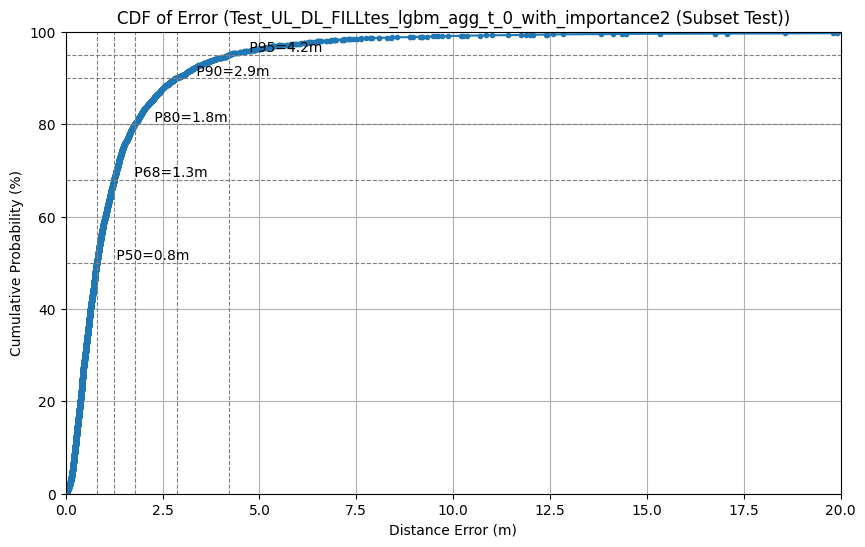


[Langkah 5/5] Membuat plot peta untuk subset pengujian...
Memplot 4129 titik dari indeks (lokal) 0 hingga 4128...


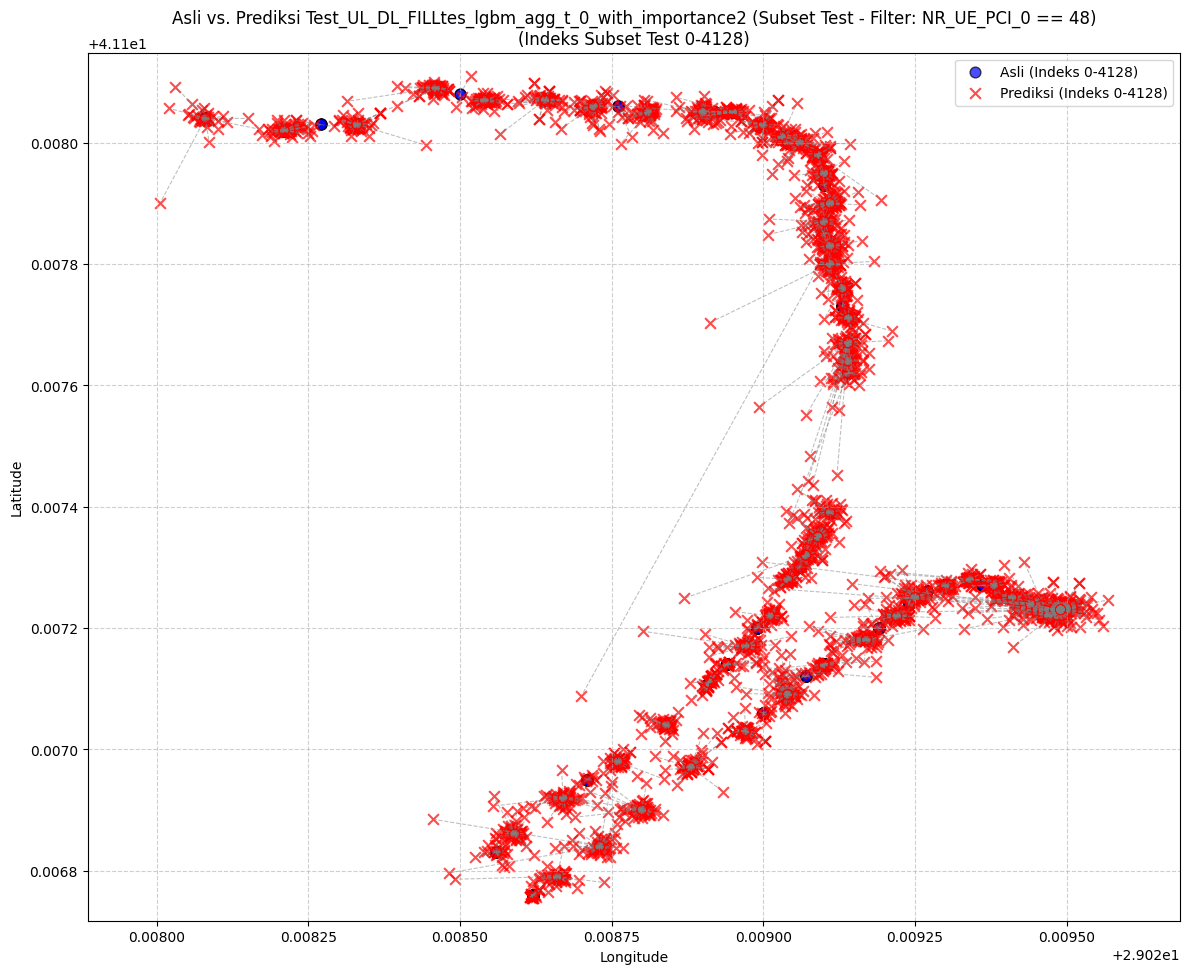


--- Feature Importance dari Model yang Dimuat ---
  Plot Feature Importance disimpan ke: results_lgbm_testing0-100\Test_UL_DL_FILLtes_lgbm_agg_t_0_with_importance2_loaded_feature_importance.png


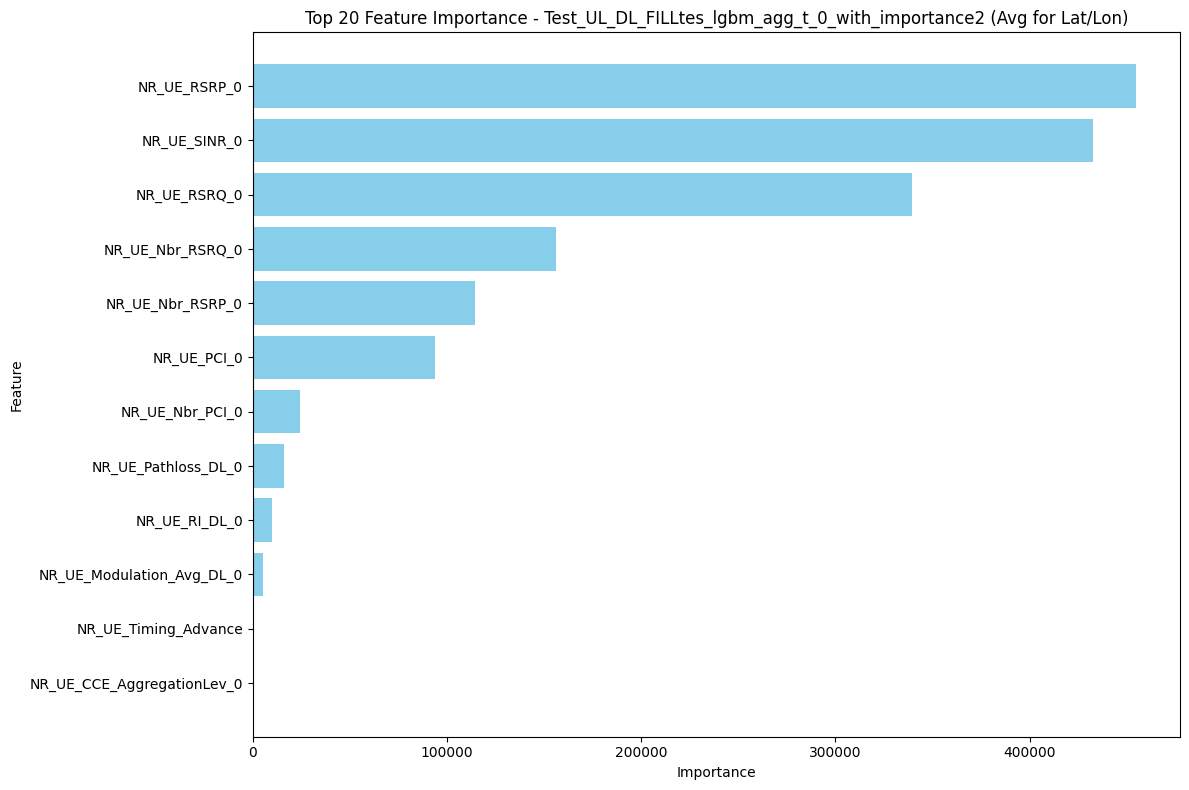


--- Skrip Pengujian Selesai dalam 21.81 detik ---


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler # Hanya untuk memuat scaler jika ada
import lightgbm as lgb # Tidak perlu untuk training, tapi baik untuk info versi
from sklearn.multioutput import MultiOutputRegressor # Untuk memuat model
from math import radians, sin, cos, sqrt, atan2, asin
import matplotlib.pyplot as plt
import joblib
import time
import os
import warnings

# Menonaktifkan beberapa jenis peringatan
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- ------------------------------------------------------------------ --- #
# ---               KONFIGURASI UTAMA (SESUAIKAN DI SINI)                --- #
# --- ------------------------------------------------------------------ --- #

# 1. Path ke DATASET PENGUJIAN Anda (bisa .xlsx atau .csv)
#    Ini adalah data yang akan digunakan untuk menguji model yang sudah ada.
#    Formatnya harus sama dengan data yang digunakan untuk training (sebelum scaling).
TEST_DATA_FILE_PATH = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/DL_fill.xlsx' # <--- GANTI INI!

# 2. Path ke MODEL dan SCALER yang Sudah Dilatih
MODEL_DIR_LGBM = "trained_models_lightgbm_aggregated" # Direktori tempat model disimpan
# Nama dasar model (tanpa _lgbm.joblib atau _scaler.joblib)
# Ini harus SAMA PERSIS dengan MODEL_BASE_NAME_LGBM saat Anda training.
SAVED_MODEL_BASE_NAME = os.path.join(MODEL_DIR_LGBM, "DL_FILLtes_lgbm_agg_t_0_with_importance2") # <--- GANTI INI!

# 3. Apakah model dilatih dengan Feature Scaling?
#    Ini harus SAMA dengan nilai USE_SCALING_LGBM saat Anda training.
MODEL_WAS_TRAINED_WITH_SCALING = False # <--- GANTI INI jika perlu

# 4. Kolom Fitur dan Target (Harus SAMA PERSIS dengan saat training)
FEATURE_COLS_FOR_TESTING = [ # <--- PASTIKAN INI SESUAI DENGAN FITUR SAAT TRAINING
    'NR_UE_PCI_0', 'NR_UE_RSRP_0', 'NR_UE_RSRQ_0', 'NR_UE_SINR_0',
    'NR_UE_Timing_Advance', 'NR_UE_Pathloss_DL_0',
    'NR_UE_Nbr_RSRQ_0', 'NR_UE_Nbr_RSRP_0', 'NR_UE_Nbr_PCI_0',
    'NR_UE_Modulation_Avg_DL_0', # Jika sudah di-encode numerik saat training
    'NR_UE_RI_DL_0',
    'NR_UE_CCE_AggregationLev_0',
    # Tambahkan fitur lain yang digunakan saat training
]
TARGET_COLS_FOR_TESTING = ['Latitude', 'Longitude']

# 5. Definisi Filter untuk SUBSET DATA PENGUJIAN
#    Sama seperti sebelumnya, Anda bisa filter berdasarkan kondisi atau indeks.
#    Biarkan kosong jika ingin menguji pada seluruh TEST_DATA_FILE_PATH.
#    Contoh:
#    TEST_SUBSET_FILTER_CONDITIONS = ["NR_UE_PCI_0 == 76", "NR_UE_RSRP_0 < -90"]
TEST_SUBSET_FILTER_CONDITIONS = [ # <--- SESUAIKAN KONDISI FILTER
    # "NR_UE_RSRP_0 < -100"
    "NR_UE_PCI_0 == 48"
]

#    Jika TEST_SUBSET_FILTER_CONDITIONS kosong, Anda bisa filter berdasarkan rentang indeks
#    pada data test yang sudah dimuat.
#    Contoh: TEST_SUBSET_START_INDEX = 100
#             TEST_SUBSET_END_INDEX = 200 (eksklusif, jadi hingga indeks 199)
#    Jika kedua variabel ini None, semua data test yang terfilter kondisi (atau semua jika tidak ada filter kondisi) akan digunakan.
TEST_SUBSET_START_INDEX = None # <--- GANTI jika ingin slice berdasarkan indeks
TEST_SUBSET_END_INDEX = None   # <--- GANTI jika ingin slice berdasarkan indeks

# 6. Output Configuration
RESULTS_DIR_TESTING = 'results_lgbm_testing0-100'
TEST_MODEL_PREFIX = f"Test_UL_{os.path.basename(SAVED_MODEL_BASE_NAME)}"

# --- ------------------------------------------------------------------ --- #
# ---                      AKHIR KONFIGURASI UTAMA                       --- #
# --- ------------------------------------------------------------------ --- #

# --- Membuat Direktori Output ---
os.makedirs(RESULTS_DIR_TESTING, exist_ok=True)

# --- Fungsi Bantuan (Haversine, plot_cdf, plot_predictions_on_map_indexed bisa dipakai ulang) ---
def haversine(lat1, lon1, lat2, lon2):
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

def plot_cdf_from_distances(distances_array, model_title_suffix, plot_save_path=None):
    # ... (fungsi ini tetap sama seperti sebelumnya) ...
    if distances_array is None or len(distances_array) == 0: print(f"No distances for CDF {model_title_suffix}."); return
    sorted_distances = np.sort(distances_array); cum_prob = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances)
    plt.figure(figsize=(10, 6)); plt.plot(sorted_distances, cum_prob * 100, marker='.', linestyle='-')
    plt.title(f'CDF of Error ({model_title_suffix})'); plt.xlabel('Distance Error (m)'); plt.ylabel('Cumulative Probability (%)')
    plt.grid(True); xlim_max = max(20, np.percentile(sorted_distances, 99.5) if len(sorted_distances) > 0 else 20)
    plt.xlim(left=0, right=xlim_max); plt.ylim(0, 100)
    percentiles = [50, 68, 80, 90, 95];
    for p in percentiles:
        if len(sorted_distances) > 0:
            val_p = np.percentile(sorted_distances, p); plt.axhline(p, color='gray', ls='--', lw=0.8); plt.axvline(val_p, color='gray', ls='--', lw=0.8)
            plt.text(min(val_p + xlim_max * 0.02, xlim_max * 0.95), p, f' P{p}={val_p:.1f}m', va='bottom', ha='left')
    if plot_save_path:
        try: plt.savefig(plot_save_path); print(f"  CDF plot saved to: {plot_save_path}")
        except Exception as e: print(f"  Error saving CDF plot: {e}")
    plt.show(); plt.close()

def plot_predictions_on_map_indexed(results_with_predictions_df, index_start, index_end, title_suffix=""):
    # ... (fungsi ini tetap sama seperti sebelumnya) ...
    if results_with_predictions_df.empty: print("DataFrame hasil prediksi kosong."); return
    if not all(c in results_with_predictions_df.columns for c in ['true_lat','true_lon','pred_lat','pred_lon']): print("Kolom plot hilang."); return
    # Ambil subset berdasarkan rentang indeks LOKAL dari results_with_predictions_df
    # (bukan indeks global dari data asli)
    actual_start = max(0, index_start)
    actual_end = min(len(results_with_predictions_df), index_end)
    if actual_start >= actual_end: print(f"Rentang indeks {index_start}-{index_end} tidak valid atau kosong untuk diplot."); return
    
    subset_to_plot = results_with_predictions_df.iloc[actual_start:actual_end]
    
    print(f"Memplot {len(subset_to_plot)} titik dari indeks (lokal) {actual_start} hingga {actual_end-1}...")
    plt.figure(figsize=(12, 10))
    plt.scatter(subset_to_plot['true_lon'],subset_to_plot['true_lat'],c='blue',label=f'Asli (Indeks {actual_start}-{actual_end-1})',alpha=0.7,s=60,edgecolor='k')
    plt.scatter(subset_to_plot['pred_lon'],subset_to_plot['pred_lat'],c='red',label=f'Prediksi (Indeks {actual_start}-{actual_end-1})',alpha=0.7,s=60,marker='x')
    for i in range(len(subset_to_plot)):
        plt.plot([subset_to_plot.iloc[i]['true_lon'],subset_to_plot.iloc[i]['pred_lon']],
                 [subset_to_plot.iloc[i]['true_lat'],subset_to_plot.iloc[i]['pred_lat']], 'grey',ls='--',lw=0.8,alpha=0.5)
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.title(f"Asli vs. Prediksi {title_suffix}\n(Indeks Subset Test {actual_start}-{actual_end-1})",fontsize=12)
    plt.legend(); plt.grid(True,ls='--',alpha=0.6); plt.axis('equal'); plt.tight_layout(); plt.show(); plt.close()


# --- Fungsi untuk Memuat Model dan Scaler (Adaptasi dari sebelumnya) ---
def load_trained_lgbm_model_and_scaler(base_model_filename, model_was_scaled):
    model_path = f"{base_model_filename}_lgbm.joblib"
    scaler_path = f"{base_model_filename}_scaler.joblib"
    
    loaded_model, loaded_scaler = None, None

    if os.path.exists(model_path):
        try:
            loaded_model = joblib.load(model_path)
            print(f"  Model LightGBM berhasil dimuat dari: {model_path}")
        except Exception as e:
            print(f"  Error saat memuat model LightGBM dari {model_path}: {e}")
            return None, None # Gagal memuat model
    else:
        print(f"  Error: File model LightGBM tidak ditemukan di {model_path}")
        return None, None

    if model_was_scaled:
        if os.path.exists(scaler_path):
            try:
                loaded_scaler = joblib.load(scaler_path)
                print(f"  Scaler berhasil dimuat dari: {scaler_path}")
            except Exception as e:
                print(f"  Error saat memuat scaler dari {scaler_path}: {e}")
                print("  PENTING: Model dilatih dengan scaling, tapi scaler gagal dimuat. Prediksi mungkin tidak akurat.")
                return loaded_model, None # Kembalikan model, tapi tandai scaler gagal
        else:
            print(f"  Error: File scaler tidak ditemukan di {scaler_path}, padahal model dilatih dengan scaling.")
            print("  PENTING: Prediksi tidak bisa dilanjutkan tanpa scaler yang sesuai.")
            return loaded_model, None # Kembalikan model, tapi tandai scaler gagal
            
    return loaded_model, loaded_scaler


# --- Fungsi untuk Mempersiapkan Data Test (Mirip load_and_prepare_data_for_lgbm) ---
def prepare_test_data(filepath, feature_cols_config, target_cols_config=['Latitude', 'Longitude']):
    print(f"Memuat dan mempersiapkan data test dari {filepath}...")
    # ... (Logika pemuatan dan pembersihan data sama seperti load_and_prepare_data_for_lgbm) ...
    # ... Pastikan semua fitur dikonversi ke numerik dengan errors='coerce' ...
    # ... dan baris dengan target NaN dibuang ...
    try:
        if filepath.endswith('.xlsx'):
            df = pd.read_excel(filepath) # Tambahkan sheet_name jika perlu
        elif filepath.endswith('.csv'):
            df = pd.read_csv(filepath, low_memory=False)
        else:
            print(f"Error: Format file tidak didukung: {filepath}"); return None, None, None
    except FileNotFoundError:
        print(f"Error: File '{filepath}' tidak ditemukan."); return None, None, None
    except Exception as e:
        print(f"Error saat membaca file: {e}"); return None, None, None

    # PENTING: Cek dan bersihkan nama kolom dari spasi ekstra
    df.columns = df.columns.str.strip()
    feature_cols_config = [col.strip() for col in feature_cols_config]
    target_cols_config = [col.strip() for col in target_cols_config]

    all_needed_cols_test = feature_cols_config + target_cols_config
    missing_cols_test = [col for col in all_needed_cols_test if col not in df.columns]
    if missing_cols_test:
        print(f"Error: Kolom yang dibutuhkan untuk testing hilang: {missing_cols_test}. Kolom tersedia: {df.columns.tolist()}"); return None, None, None

    df_subset_test = df[all_needed_cols_test].copy()
    print("  Konversi kolom fitur test ke numerik...")
    for col in feature_cols_config:
        df_subset_test[col] = pd.to_numeric(df_subset_test[col], errors='coerce')
        # Di sini kita TIDAK imputasi NaN. Model LightGBM akan menanganinya.
        # Jika model lain, atau jika scaler digunakan dan tidak bisa handle NaN, perlu imputasi.

    # Buang baris jika target (Lat/Lon) adalah NaN
    df_clean_test = df_subset_test.dropna(subset=target_cols_config).reset_index(drop=True)
    
    print(f"  Data Test: Baris awal: {len(df)}, Baris setelah cleaning targets: {len(df_clean_test)}")
    if df_clean_test.empty:
        print("  Error: Tidak ada data test yang bisa digunakan."); return None, None, None
    
    return df_clean_test[feature_cols_config], df_clean_test[target_cols_config], df_clean_test # Return y sebagai DataFrame

# --- Fungsi untuk Feature Importance (Sama seperti sebelumnya) ---
def plot_feature_importance(model, feature_names, model_name="LightGBM", top_n=20, save_path=None):
    # ... (fungsi ini tetap sama seperti sebelumnya) ...
    if not hasattr(model, 'estimators_'):
        if hasattr(model, 'feature_importances_'): importances_single = model.feature_importances_
        else: print(f"Model {model_name} tidak memiliki 'estimators_' atau 'feature_importances_'."); return None
        feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances_single})
        title = f"Top {top_n} Feature Importance - {model_name} (Single Estimator)"
    else:
        importances_lat = model.estimators_[0].feature_importances_
        importances_lon = model.estimators_[1].feature_importances_
        avg_importances = (importances_lat + importances_lon) / 2
        feature_importance_df = pd.DataFrame({'feature':feature_names,'importance_lat':importances_lat,'importance_lon':importances_lon,'importance_avg':avg_importances})
        feature_importance_df = feature_importance_df.sort_values(by='importance_avg', ascending=False)
        title = f"Top {top_n} Feature Importance - {model_name} (Avg for Lat/Lon)"

    feature_importance_df = feature_importance_df.head(top_n)
    plt.figure(figsize=(12, int(max(8,top_n*0.4))));
    y_pos = np.arange(len(feature_importance_df))
    plot_values = feature_importance_df['importance_avg'] if 'importance_avg' in feature_importance_df else feature_importance_df['importance']
    plt.barh(y_pos, plot_values, align='center', color='skyblue')
    plt.yticks(y_pos, feature_importance_df['feature'])
    plt.xlabel("Importance"); plt.ylabel("Feature"); plt.title(title)
    plt.gca().invert_yaxis(); plt.tight_layout()
    if save_path:
        try: plt.savefig(save_path); print(f"  Plot Feature Importance disimpan ke: {save_path}")
        except Exception as e: print(f"  Error menyimpan plot Feature Importance: {e}")
    plt.show(); plt.close()
    return feature_importance_df

# --- Main Testing Script ---
if __name__ == '__main__':
    print("--- Skrip Pengujian Model LightGBM Dimulai ---")
    script_start_time = time.time()

    # 1. Muat Model dan Scaler yang Sudah Dilatih
    print(f"\n[Langkah 1/5] Memuat model dan scaler dari: {SAVED_MODEL_BASE_NAME}...")
    lgbm_model_loaded, scaler_loaded = load_trained_lgbm_model_and_scaler(
        SAVED_MODEL_BASE_NAME,
        MODEL_WAS_TRAINED_WITH_SCALING
    )

    if lgbm_model_loaded is None:
        print("FATAL: Gagal memuat model. Tidak bisa melanjutkan pengujian.")
        exit()
    if MODEL_WAS_TRAINED_WITH_SCALING and scaler_loaded is None:
        print("FATAL: Model dilatih dengan scaling, tapi scaler gagal dimuat. Tidak bisa melanjutkan pengujian.")
        exit()

    # 2. Muat dan Persiapkan Data Pengujian
    print(f"\n[Langkah 2/5] Memuat dan mempersiapkan data pengujian dari: {TEST_DATA_FILE_PATH}...")
    X_test_full_raw, y_test_full_latlon, df_test_full_clean = prepare_test_data(
        TEST_DATA_FILE_PATH,
        FEATURE_COLS_FOR_TESTING,
        TARGET_COLS_FOR_TESTING
    )

    if X_test_full_raw is None or X_test_full_raw.empty:
        print("FATAL: Gagal memuat atau mempersiapkan data pengujian. Skrip dihentikan.")
        exit()

    # 3. Filter Subset Data Pengujian (Jika Didefinisikan)
    print(f"\n[Langkah 3/5] Menerapkan filter pada data pengujian (jika ada)...")
    X_test_subset = X_test_full_raw.copy()
    y_test_subset_latlon = y_test_full_latlon.copy()
    df_test_subset_clean = df_test_full_clean.copy() # Untuk menjaga indeks asli saat plotting

    # Gabungkan X dan y sementara untuk filtering yang mudah
    temp_df_for_filtering = pd.concat([X_test_full_raw.reset_index(drop=True), 
                                       y_test_full_latlon.reset_index(drop=True)], axis=1)
    
    # Simpan indeks asli sebelum filter untuk mapping kembali ke df_test_full_clean nanti
    original_indices_before_filter = temp_df_for_filtering.index.copy()


    if TEST_SUBSET_FILTER_CONDITIONS:
        print("  Menerapkan filter kondisi pada data pengujian:")
        current_filtered_df = temp_df_for_filtering.copy()
        for cond in TEST_SUBSET_FILTER_CONDITIONS:
            try:
                current_filtered_df = current_filtered_df.query(cond)
                print(f"    Setelah filter '{cond}': {len(current_filtered_df)} baris tersisa.")
            except Exception as e:
                print(f"    Peringatan: Error pada filter pengujian '{cond}': {e}. Filter diabaikan untuk kondisi ini.")
        
        X_test_subset = current_filtered_df[FEATURE_COLS_FOR_TESTING]
        y_test_subset_latlon = current_filtered_df[TARGET_COLS_FOR_TESTING]
        # Pertahankan df_test_subset_clean dengan indeks yang sesuai
        df_test_subset_clean = df_test_full_clean.loc[current_filtered_df.index]


    elif TEST_SUBSET_START_INDEX is not None and TEST_SUBSET_END_INDEX is not None:
        print(f"  Mengambil subset data pengujian berdasarkan rentang indeks: {TEST_SUBSET_START_INDEX} hingga {TEST_SUBSET_END_INDEX-1}")
        X_test_subset = X_test_full_raw.iloc[TEST_SUBSET_START_INDEX:TEST_SUBSET_END_INDEX]
        y_test_subset_latlon = y_test_full_latlon.iloc[TEST_SUBSET_START_INDEX:TEST_SUBSET_END_INDEX]
        df_test_subset_clean = df_test_full_clean.iloc[TEST_SUBSET_START_INDEX:TEST_SUBSET_END_INDEX]
    else:
        print("  Tidak ada filter subset khusus yang diterapkan pada data pengujian. Menggunakan semua data test yang dimuat.")
        # X_test_subset dan y_test_subset_latlon sudah berisi semua data test yang bersih

    if X_test_subset.empty:
        print("FATAL: Tidak ada data tersisa untuk diuji setelah filter. Periksa kondisi filter Anda.")
        exit()
        
    print(f"  Jumlah sampel data pengujian yang akan digunakan: {len(X_test_subset)}")

# ... (kode di atasnya) ...

# --- Fungsi Bantuan (Haversine, plot_cdf, plot_predictions_on_map_indexed bisa dipakai ulang) ---
def haversine(lat1, lon1, lat2, lon2):
    # ... (isi fungsi haversine tetap sama) ...
    if any(pd.isna([lat1, lon1, lat2, lon2])): return np.nan
    lon1, lat1, lon2, lat2 = map(radians, [float(lon1), float(lat1), float(lon2), float(lat2)])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a)); r = 6371
    return c * r * 1000

# --- BARU: Fungsi Perhitungan Error yang Lebih Generik ---
def calculate_error_metrics_and_details(y_true_latlon_df, y_pred_latlon_array, model_prefix_for_print="Model"):
    """
    Menghitung jarak error dan mengembalikan array error serta DataFrame detail.
    y_true_latlon_df: DataFrame dengan kolom target (misal, 'Latitude', 'Longitude').
    y_pred_latlon_array: NumPy array hasil prediksi model, kolom 0 = pred_lat, kolom 1 = pred_lon.
    """
    print(f"  ({model_prefix_for_print}) Menghitung metrik error...")
    errors = []
    error_details_list = []
    invalid_predictions = 0

    # Pastikan y_true_latlon_df adalah DataFrame dan memiliki kolom target yang benar
    # Asumsi TARGET_COLS_FOR_TESTING adalah list global ['Latitude', 'Longitude']
    true_lat_col_name = TARGET_COLS_FOR_TESTING[0]
    true_lon_col_name = TARGET_COLS_FOR_TESTING[1]

    if not isinstance(y_true_latlon_df, pd.DataFrame) or \
       not all(col in y_true_latlon_df.columns for col in [true_lat_col_name, true_lon_col_name]):
        print(f"    Peringatan: y_true_latlon_df bukan DataFrame yang valid atau kolom target hilang.")
        return np.array([]), pd.DataFrame()

    if not isinstance(y_pred_latlon_array, np.ndarray) or y_pred_latlon_array.shape[1] != 2:
        print(f"    Peringatan: y_pred_latlon_array bukan array NumPy yang valid.")
        return np.array([]), pd.DataFrame()

    if len(y_true_latlon_df) != len(y_pred_latlon_array):
        print(f"    Peringatan: Jumlah baris y_true dan y_pred tidak cocok.")
        return np.array([]), pd.DataFrame()

    # Gunakan indeks asli dari y_true_latlon_df untuk error_details_list jika ada
    # Ini membantu saat menggabungkan kembali dengan results_df_test_subset
    original_indices = y_true_latlon_df.index

    for i in range(len(y_true_latlon_df)):
        true_lat = y_true_latlon_df.iloc[i][true_lat_col_name]
        true_lon = y_true_latlon_df.iloc[i][true_lon_col_name]
        pred_lat = y_pred_latlon_array[i, 0]
        pred_lon = y_pred_latlon_array[i, 1]

        current_error_detail = {
            'original_index': original_indices[i], # Simpan indeks asli
            'true_lat': true_lat, 'true_lon': true_lon,
            'pred_lat': pred_lat, 'pred_lon': pred_lon,
            'error_m': np.nan
        }

        if not (pd.notna(true_lat) and pd.notna(true_lon) and pd.notna(pred_lat) and pd.notna(pred_lon)):
            invalid_predictions += 1
        elif not (-90 <= pred_lat <= 90 and -180 <= pred_lon <= 180):
            invalid_predictions += 1
        else:
            try:
                distance = haversine(true_lat, true_lon, pred_lat, pred_lon)
                errors.append(distance)
                current_error_detail['error_m'] = distance
            except ValueError:
                invalid_predictions += 1
        
        error_details_list.append(current_error_detail)

    print(f"    Selesai menghitung error untuk {len(errors)} prediksi valid. Prediksi tidak valid/dilewati: {invalid_predictions}.")
    return np.array(errors), pd.DataFrame(error_details_list)


# 4. Lakukan Prediksi dan Evaluasi pada Subset Pengujian
print(f"\n[Langkah 4/5] Melakukan prediksi dan evaluasi pada subset pengujian...")

X_test_for_prediction = X_test_subset.copy()
if MODEL_WAS_TRAINED_WITH_SCALING and scaler_loaded:
    print("  Menerapkan scaling pada fitur test...")
    X_test_for_prediction = scaler_loaded.transform(X_test_subset)
elif MODEL_WAS_TRAINED_WITH_SCALING and not scaler_loaded:
    print("FATAL: Model dilatih dengan scaling, tapi scaler tidak berhasil dimuat. Tidak bisa melanjutkan."); exit()

try:
    y_pred_test_array = lgbm_model_loaded.predict(X_test_for_prediction)
except Exception as e:
    print(f"FATAL: Error saat melakukan prediksi pada data test: {e}"); exit()

# --- PERBAIKAN DI SINI ---
# Hitung error menggunakan fungsi baru
test_errors_array, test_error_details_df_with_idx = calculate_error_metrics_and_details(
    y_test_subset_latlon, # Ini adalah DataFrame target untuk subset test
    y_pred_test_array,
    TEST_MODEL_PREFIX
)
# -------------------------

# Buat results_df_test_subset dari test_error_details_df_with_idx
# Kita ingin mempertahankan indeks asli dari X_test_subset / y_test_subset_latlon
# Fungsi calculate_error_metrics_and_details sekarang menyimpan 'original_index'
# Mari kita gunakan itu untuk membuat results_df dengan benar jika diperlukan,
# atau lebih sederhana, kita bisa buat results_df dari awal dan merge error_m.

results_df_test_subset = pd.DataFrame({
    'true_lat': y_test_subset_latlon[TARGET_COLS_FOR_TESTING[0]].values,
    'true_lon': y_test_subset_latlon[TARGET_COLS_FOR_TESTING[1]].values,
    'pred_lat': y_pred_test_array[:, 0],
    'pred_lon': y_pred_test_array[:, 1]
}, index=y_test_subset_latlon.index) # Gunakan indeks dari y_test_subset_latlon

# Gabungkan error_m ke results_df_test_subset menggunakan indeks aslinya jika ada
if not test_error_details_df_with_idx.empty:
    # Set 'original_index' sebagai indeks di df detail error agar bisa di-join/map
    error_m_series = test_error_details_df_with_idx.set_index('original_index')['error_m']
    results_df_test_subset['error_m'] = results_df_test_subset.index.map(error_m_series)


# Simpan detail error (sekarang test_error_details_df_with_idx sudah berisi semua info)
TEST_ERROR_CSV_PATH = os.path.join(RESULTS_DIR_TESTING, f'{TEST_MODEL_PREFIX}_subset_errors_detail.csv')
if not test_error_details_df_with_idx.empty: # Gunakan DataFrame yang berisi semua detail
    test_error_details_df_with_idx.to_csv(TEST_ERROR_CSV_PATH, index=False, float_format='%.6f') # Simpan tanpa indeks df
    print(f"  Detail error subset test disimpan ke: {TEST_ERROR_CSV_PATH}")

# Tampilkan Metrik dan Plot CDF (menggunakan test_errors_array yang sudah bersih dari NaN)
if len(test_errors_array) > 0:
    # ... (kode metrik dan CDF tetap sama) ...
    mean_test_err = np.mean(test_errors_array); median_test_err = np.median(test_errors_array)
    rmse_test_err = np.sqrt(np.mean(np.square(test_errors_array)))
    print("\n--- Performa pada Subset Test ---")
    print(f"Model: {TEST_MODEL_PREFIX}"); print(f"Jumlah titik subset test dievaluasi: {len(test_errors_array)}")
    print(f"Filter diterapkan: {TEST_SUBSET_FILTER_CONDITIONS if TEST_SUBSET_FILTER_CONDITIONS else 'Tidak ada (atau by index)'}")
    if TEST_SUBSET_START_INDEX is not None : print(f"Rentang Indeks Global (dari file test asli): {df_test_full_clean.iloc[TEST_SUBSET_START_INDEX:TEST_SUBSET_END_INDEX].index[0] if TEST_SUBSET_END_INDEX > TEST_SUBSET_START_INDEX else 'N/A'}-{df_test_full_clean.iloc[TEST_SUBSET_START_INDEX:TEST_SUBSET_END_INDEX].index[-1] if TEST_SUBSET_END_INDEX > TEST_SUBSET_START_INDEX else 'N/A'}")
    print(f"Mean Error:   {mean_test_err:.2f} m"); print(f"Median Error: {median_test_err:.2f} m"); print(f"RMSE:         {rmse_test_err:.2f} m")
    percentiles = [50, 68, 80, 90, 95]; percentile_vals = np.percentile(test_errors_array, percentiles)
    print("\nPersentil Error (CDF):"); print(" , ".join([f"{p}th: {v:.2f}m" for p,v in zip(percentiles, percentile_vals)])); print("-------------------------\n")
    
    TEST_PLOT_CDF_PATH = os.path.join(RESULTS_DIR_TESTING, f'{TEST_MODEL_PREFIX}_subset_test_cdf.png')
    plot_cdf_from_distances(test_errors_array, f"{TEST_MODEL_PREFIX} (Subset Test)", TEST_PLOT_CDF_PATH)
else:
    print("Tidak ada error valid yang dihitung untuk subset test.")

# 5. Visualisasi Peta Prediksi vs. Asli pada Subset Pengujian
print(f"\n[Langkah 5/5] Membuat plot peta untuk subset pengujian...")
# Sekarang results_df_test_subset sudah memiliki semua kolom yang dibutuhkan
# dan indeksnya sesuai dengan y_test_subset_latlon / X_test_subset
if not results_df_test_subset.empty:
    plot_idx_start = 0
    plot_idx_end = len(results_df_test_subset)
    # ... (sisa kode plotting peta sama, menggunakan results_df_test_subset) ...
    plot_title = f"{TEST_MODEL_PREFIX} (Subset Test"
    if TEST_SUBSET_FILTER_CONDITIONS:
        plot_title += f" - Filter: {' AND '.join(TEST_SUBSET_FILTER_CONDITIONS)}"
    elif TEST_SUBSET_START_INDEX is not None:
            # Dapatkan indeks global asli untuk judul plot
            global_start_idx = df_test_subset_clean.index[0] if not df_test_subset_clean.empty else TEST_SUBSET_START_INDEX
            global_end_idx = df_test_subset_clean.index[-1] if not df_test_subset_clean.empty else TEST_SUBSET_END_INDEX -1
            plot_title += f" - Indeks Global Asli: {global_start_idx}-{global_end_idx}"
    plot_title += ")"

    plot_predictions_on_map_indexed(
        results_df_test_subset, 
        plot_idx_start, # Plot semua dari subset yang sudah difilter/slice
        plot_idx_end,
        title_suffix=plot_title
    )
else:
    print("Tidak ada hasil prediksi pada subset untuk diplot.")
    
# ... (sisa kode, feature importance, dll.) ...
# Tampilkan Feature Importance dari model yang dimuat
print("\n--- Feature Importance dari Model yang Dimuat ---")
# Nama fitur harus sesuai dengan yang digunakan saat model dilatih (FEATURE_COLS_FOR_TESTING)
fi_plot_save_path = os.path.join(RESULTS_DIR_TESTING, f"{TEST_MODEL_PREFIX}_loaded_feature_importance.png")
plot_feature_importance(lgbm_model_loaded, FEATURE_COLS_FOR_TESTING, model_name=TEST_MODEL_PREFIX, save_path=fi_plot_save_path)


script_total_time = time.time() - script_start_time
print(f"\n--- Skrip Pengujian Selesai dalam {script_total_time:.2f} detik ---")